In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
import plotly.graph_objects as go
import plotly.express as px
import math

In [2]:
df = pd.read_csv('IoTPond12.csv')
df.head()

,created_at,entry_id,TEMPERATURE,TURBIDITY,DISOLVED OXYGEN,pH,AMMONIA,NITRATE,Population,Length,Weight
0,2021-06-25 15:14:09 CET,1,27.0,100,0.000,6.05951,0.00013,90,50,14.64,28.6
1,2021-06-25 15:14:28 CET,2,27.0,100,1.027,6.00049,0.00000,201,50,14.64,28.6
2,2021-06-25 15:14:53 CET,3,27.0,100,0.000,6.07766,0.00001,112,50,14.64,28.6
3,2021-06-25 15:15:49 CET,4,27.0,100,0.000,6.05043,0.00012,153,50,14.64,28.6
4,2021-06-25 15:18:36 CET,5,27.0,100,0.000,6.06858,0.00027,272,50,14.64,28.6


In [3]:
print(df.isnull().sum())

created_at         0
entry_id           0
TEMPERATURE        0
TURBIDITY          0
DISOLVED OXYGEN    0
pH                 0
AMMONIA            0
NITRATE            0
Population         0
Length             0
Weight             0
dtype: int64


In [4]:
df.drop(columns=['entry_id','Population'],axis=1,inplace=True)

In [5]:
df.describe()

,TEMPERATURE,TURBIDITY,DISOLVED OXYGEN,pH,AMMONIA,NITRATE,Length,Weight
count,3590.000000,3590.000000,3590.000000,3590.000000,3.590000e+03,3590.000000,3590.000000,3590.000000
mean,25.863196,51.737047,19.402811,6.048149,1.750208e+08,1093.273259,39.457959,547.709719
std,2.612486,5.965064,5.765773,0.496000,7.317914e+09,248.017126,3.819124,122.575264
min,-127.000000,51.000000,0.000000,4.774840,0.000000e+00,0.000000,14.640000,28.600000
25%,25.500000,51.000000,15.961500,5.719050,0.000000e+00,971.000000,39.959290,576.428600
50%,25.875000,51.000000,18.306000,6.082200,3.890695e+00,1040.000000,41.267134,605.357114
75%,26.375000,51.000000,21.778000,6.468060,3.608240e+01,1163.000000,41.396420,613.142800
max,27.125000,100.000000,42.261000,6.940160,4.260000e+11,4095.000000,41.662130,620.928500


In [6]:
df.columns

Index(['created_at', 'TEMPERATURE', 'TURBIDITY', 'DISOLVED OXYGEN', 'pH',
       'AMMONIA', 'NITRATE', 'Length', 'Weight'],
      dtype='object')

In [7]:
df.shape

(3590, 9)

In [8]:
df['created_at'] = pd.to_datetime(df['created_at'], infer_datetime_format=True, utc=True)

In [9]:
df['created_at'] = pd.to_datetime(df.created_at)

#split columns
df["Date"] = df["created_at"].dt.day
df["month"] = df["created_at"].dt.month
df['year']=df['created_at'].dt.year
df['hour']=df['created_at'].dt.hour
df['minutes']=df['created_at'].dt.minute
df['seconds']=df['created_at'].dt.second

In [10]:
df.head()

,created_at,TEMPERATURE,TURBIDITY,DISOLVED OXYGEN,pH,AMMONIA,NITRATE,Length,Weight,Date,month,year,hour,minutes,seconds
0,2021-06-25 15:14:09+00:00,27.0,100,0.000,6.05951,0.00013,90,14.64,28.6,25,6,2021,15,14,9
1,2021-06-25 15:14:28+00:00,27.0,100,1.027,6.00049,0.00000,201,14.64,28.6,25,6,2021,15,14,28
2,2021-06-25 15:14:53+00:00,27.0,100,0.000,6.07766,0.00001,112,14.64,28.6,25,6,2021,15,14,53
3,2021-06-25 15:15:49+00:00,27.0,100,0.000,6.05043,0.00012,153,14.64,28.6,25,6,2021,15,15,49
4,2021-06-25 15:18:36+00:00,27.0,100,0.000,6.06858,0.00027,272,14.64,28.6,25,6,2021,15,18,36


In [11]:
df.drop(["created_at"], axis = 1, inplace = True)

In [12]:
 df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df['Date'] = pd.to_numeric(df['Date'])

In [13]:
 df['month'] = pd.to_datetime(df['month'], errors='coerce')

df['month'] = pd.to_numeric(df['month'])

In [14]:
 df['year'] = pd.to_datetime(df['year'], errors='coerce')

df['year'] = pd.to_numeric(df['year'])

In [15]:
df['hour'] = pd.to_datetime(df['hour'], errors='coerce')

df['hour'] = pd.to_numeric(df['hour'])

In [16]:
df['minutes'] = pd.to_datetime(df['minutes'], errors='coerce')

df['minutes'] = pd.to_numeric(df['minutes'])

In [17]:
df['seconds'] = pd.to_datetime(df['seconds'], errors='coerce')

df['seconds'] = pd.to_numeric(df['seconds'])

In [18]:
df.fillna(df.mean(), inplace=True)
df.replace([np.inf, -np.inf], 1e-9, inplace=True)

In [19]:
for i in range(len(df)):
    if df.loc[i, "TEMPERATURE"] < 20 or df.loc[i, "TEMPERATURE"] > 30:
        df.loc[i, "TEMPERATURE"] = df.loc[i-1, "TEMPERATURE"]

In [20]:
for i in range(1,len(df)):
    if df.loc[i, "pH"] < 6 or df.loc[i, "pH"] > 8.5:
        df.loc[i, "pH"] = df.loc[i-1,'pH']

In [21]:
df.at[0,'DISOLVED OXYGEN']=10

In [22]:
for i in range(1,len(df)):
    if df.loc[i, "DISOLVED OXYGEN"] < 5 or df.loc[i, "DISOLVED OXYGEN"] > 20:
        df.loc[i, "DISOLVED OXYGEN"] = df.loc[i-1, "DISOLVED OXYGEN"]

In [23]:
df["AMMONIA"] = np.log(df["AMMONIA"]) / 10.0
df["AMMONIA"] = df["AMMONIA"].abs()


In [24]:
df["NITRATE"] = df["NITRATE"].apply(np.sqrt)

In [25]:
df.describe()

,TEMPERATURE,TURBIDITY,DISOLVED OXYGEN,pH,AMMONIA,NITRATE,Length,Weight,Date,month,year,hour,minutes,seconds
count,3590.000000,3590.000000,3590.000000,3590.000000,3590.000000,3590.000000,3590.000000,3590.000000,3590.000000,3590.000000,3590.000000,3590.000000,3590.000000,3590.000000
mean,25.906128,51.737047,17.048385,6.287884,inf,32.842150,39.457959,547.709719,15.566017,6.792758,2021.364624,0.108635,0.156546,0.218942
std,0.559386,5.965064,2.025314,0.239981,NaN,3.830210,3.819124,122.575264,7.528970,4.498469,0.481392,1.272075,1.870123,2.929748
min,24.687500,51.000000,5.795000,6.000490,0.011069,0.000000,14.640000,28.600000,1.000000,1.000000,2021.000000,0.000000,0.000000,0.000000
25%,25.500000,51.000000,15.898000,6.068580,0.193402,31.160873,39.959290,576.428600,12.000000,2.000000,2021.000000,0.000000,0.000000,0.000000
50%,25.875000,51.000000,16.958000,6.315985,0.481792,32.249031,41.267134,605.357114,19.000000,10.000000,2021.000000,0.000000,0.000000,0.000000
75%,26.375000,51.000000,18.611000,6.468060,NaN,34.102786,41.396420,613.142800,21.000000,11.000000,2022.000000,0.000000,0.000000,0.000000
max,27.125000,100.000000,19.992000,6.940160,inf,63.992187,41.662130,620.928500,25.000000,12.000000,2022.000000,15.000000,29.000000,56.000000


In [26]:
df.replace([np.inf, -np.inf], 1e-9, inplace=True)

In [27]:
columns=df.columns.tolist()
columns=columns[-6:]+columns[0:-6]
df=df[columns]

In [28]:
df.head()

,Date,month,year,hour,minutes,seconds,TEMPERATURE,TURBIDITY,DISOLVED OXYGEN,pH,AMMONIA,NITRATE,Length,Weight
0,25,6,2021,15,14,9,27.0,100,10.0,6.05951,8.947976e-01,9.486833,14.64,28.6
1,25,6,2021,15,14,28,27.0,100,10.0,6.00049,1.000000e-09,14.177447,14.64,28.6
2,25,6,2021,15,14,53,27.0,100,10.0,6.07766,1.151293e+00,10.583005,14.64,28.6
3,25,6,2021,15,15,49,27.0,100,10.0,6.05043,9.028019e-01,12.369317,14.64,28.6
4,25,6,2021,15,18,36,27.0,100,10.0,6.06858,8.217089e-01,16.492423,14.64,28.6


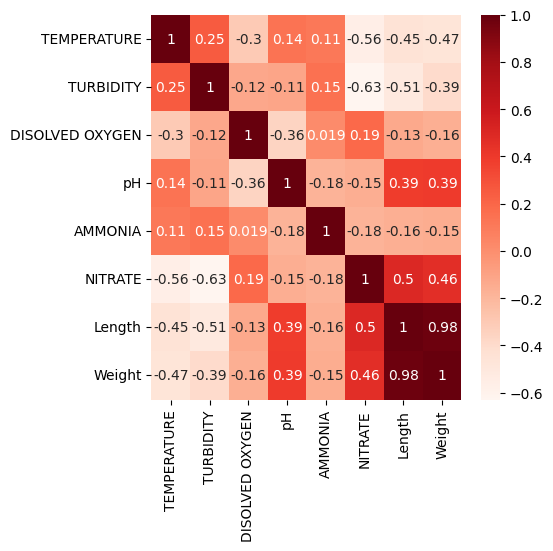

In [29]:
#creating a heatmap to show the correlation between the features
plt.figure(figsize=(5, 5))
x=df.iloc[:,6:]
cor = x.corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.Reds)
plt.show()

In [30]:
df.describe()

,Date,month,year,hour,minutes,seconds,TEMPERATURE,TURBIDITY,DISOLVED OXYGEN,pH,AMMONIA,NITRATE,Length,Weight
count,3590.000000,3590.000000,3590.000000,3590.000000,3590.000000,3590.000000,3590.000000,3590.000000,3590.000000,3590.000000,3.590000e+03,3590.000000,3590.000000,3590.000000
mean,15.566017,6.792758,2021.364624,0.108635,0.156546,0.218942,25.906128,51.737047,17.048385,6.287884,2.791401e-01,32.842150,39.457959,547.709719
std,7.528970,4.498469,0.481392,1.272075,1.870123,2.929748,0.559386,5.965064,2.025314,0.239981,3.669143e-01,3.830210,3.819124,122.575264
min,1.000000,1.000000,2021.000000,0.000000,0.000000,0.000000,24.687500,51.000000,5.795000,6.000490,1.000000e-09,0.000000,14.640000,28.600000
25%,12.000000,2.000000,2021.000000,0.000000,0.000000,0.000000,25.500000,51.000000,15.898000,6.068580,1.000000e-09,31.160873,39.959290,576.428600
50%,19.000000,10.000000,2021.000000,0.000000,0.000000,0.000000,25.875000,51.000000,16.958000,6.315985,1.423583e-01,32.249031,41.267134,605.357114
75%,21.000000,11.000000,2022.000000,0.000000,0.000000,0.000000,26.375000,51.000000,18.611000,6.468060,3.738219e-01,34.102786,41.396420,613.142800
max,25.000000,12.000000,2022.000000,15.000000,29.000000,56.000000,27.125000,100.000000,19.992000,6.940160,2.677771e+00,63.992187,41.662130,620.928500


In [31]:
df.to_csv('pp12.csv', index=False)